In [1]:
#!/usr/bin/env python3
# coding: utf-8

"""
File: optimization_manager.py
Author: Matthew Ogden
Email: ogdenm12@gmail.com
Github: mbogden
Created: 2024-Nov-11

References:  Sections of this code were enhanced with the assistance of ChatGPT made by OpenAI.
"""

# ================================ STANDARD IMPORTS ================================ #
import logging
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# partial imports
from mpi4py import MPI
from skopt import Optimizer
from skopt.space import Real
from skopt.sampler import Lhs, Sobol

# ================================ PROJECT MODULES ================================ #
# Add main project directory to import project modules
try:
    SCRIPT_DIRECTORY = os.path.dirname(os.path.realpath(__file__))
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    sys.path.append(PROJECT_DIRECTORY)

except:
    # Assume we are running from the script directory
    SCRIPT_DIRECTORY = os.getcwd()
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    
    # Also assume you might be in galStuff
    work_dir = os.getcwd()
    if 'galStuff' == work_dir.split('/')[-1]:
        PROJECT_DIRECTORY =  work_dir + '/galaxyJSPAM'
        sys.path.append(PROJECT_DIRECTORY)

# import project modules
import utilities.general_utility as gu
import utilities.parallel_queue_manager as qm

# ================================ GLOBAL VARIABLES ================================ #
buildEnv = False

# Global logger from main program
SCRIPTS_ARGUMENTS, logger = gu.initialize_environment(module_name='optimizer') # Testing using multiple loggers for tiered log levels.
# SCRIPTS_ARGUMENTS, logger = gu.initialize_environment(module_name='') 

# Generate random instance
rng = np.random.default_rng()

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-ctc12zqm because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# Development Cell:  This should only be present in the Jupyter Notebook version of this script for development purposes.
buildEnv = True

from importlib import reload

# Warn user if NOT in jupyter notebook, require a yes/no response to continue or not
if "ipykernel" not in sys.modules:
    msg = "Development Environment Detected.  This will run several tests and attempt to creat plots.  Do you want to continue?..."

    # Get user input
    while True:
        response = input(f"{msg} (y/n): ").lower()
        if response in ['y', 'yes']:
            break
        elif response in ['n', 'no']:
            print("Exiting...")
            sys.exit()
        else:
            print("Invalid input. Please enter 'y' or 'n'.")



[2025-03-11 11:13:14,043 - INFO - 955837437.test_space_manager]: Testing Space Manager
[2025-03-11 11:13:14,044 - INFO - 955837437.__init__]: Initializing Space Manager
[2025-03-11 11:13:14,049 - INFO - 955837437.__init__]: Space Manager Initialized



Testing Space Manager with Input Space:
{'name': 'uni-orig', 'type': 'float', 'bounds': [-100, 100], 'prior': 'uniform', 'transform': 'identity'}
{'name': 'uni-norm', 'type': 'float', 'bounds': [-100, 100], 'prior': 'uniform', 'transform': 'normalize'}
{'name': 'log-orig', 'type': 'float', 'bounds': [0.01, 100], 'prior': 'log-uniform', 'transform': 'identity'}
{'name': 'log-norm', 'type': 'float', 'bounds': [0.01, 100], 'prior': 'log-uniform', 'transform': 'normalize'}

Random Samples


[2025-03-11 11:13:14,212 - INFO - 955837437.hist_samples]: Histogram Samples
[2025-03-11 11:13:14,213 - INFO - 955837437.hist_samples]: Space Names: ['uni-orig', 'uni-norm', 'log-orig', 'log-norm']
[2025-03-11 11:13:14,214 - INFO - 955837437.hist_samples]: [-7.07e+01  7.23e+01  1.17e+00  1.25e-02] - Original Samples
[2025-03-11 11:13:14,215 - INFO - 955837437.hist_samples]: [-9.05e+01  1.33e-02  3.48e-01  5.91e-01] - Normalized Samples


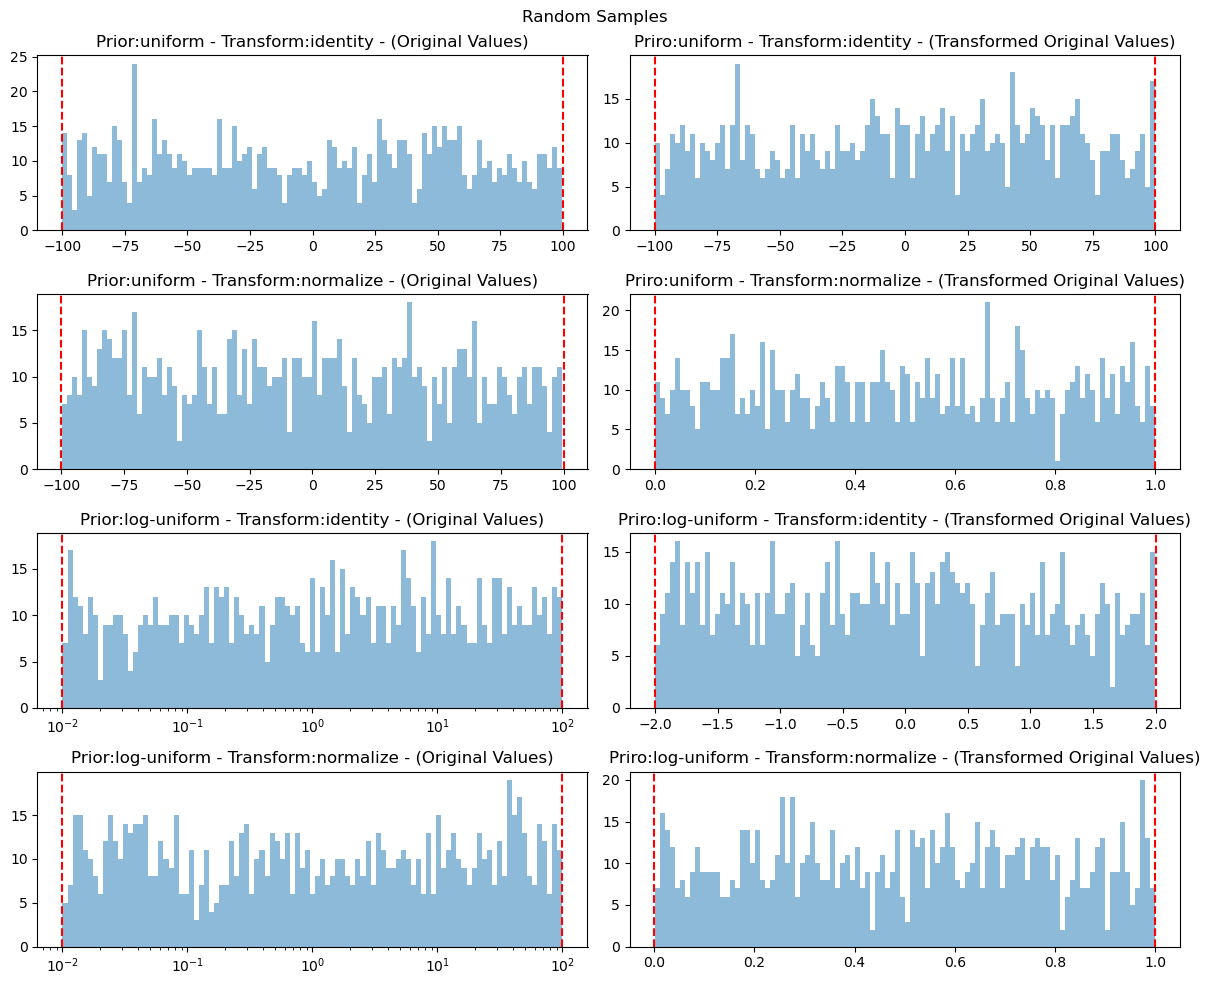

[2025-03-11 11:13:17,723 - INFO - 955837437.hist_samples]: Histogram Samples
[2025-03-11 11:13:17,725 - INFO - 955837437.hist_samples]: Space Names: ['uni-orig', 'uni-norm', 'log-orig', 'log-norm']
[2025-03-11 11:13:17,726 - INFO - 955837437.hist_samples]: [-1.00e+02 -1.00e+02  1.00e-02  1.00e-02] - Original Samples
[2025-03-11 11:13:17,727 - INFO - 955837437.hist_samples]: [-1.00e+02  0.00e+00 -2.00e+00  0.00e+00] - Normalized Samples


Grid Samples


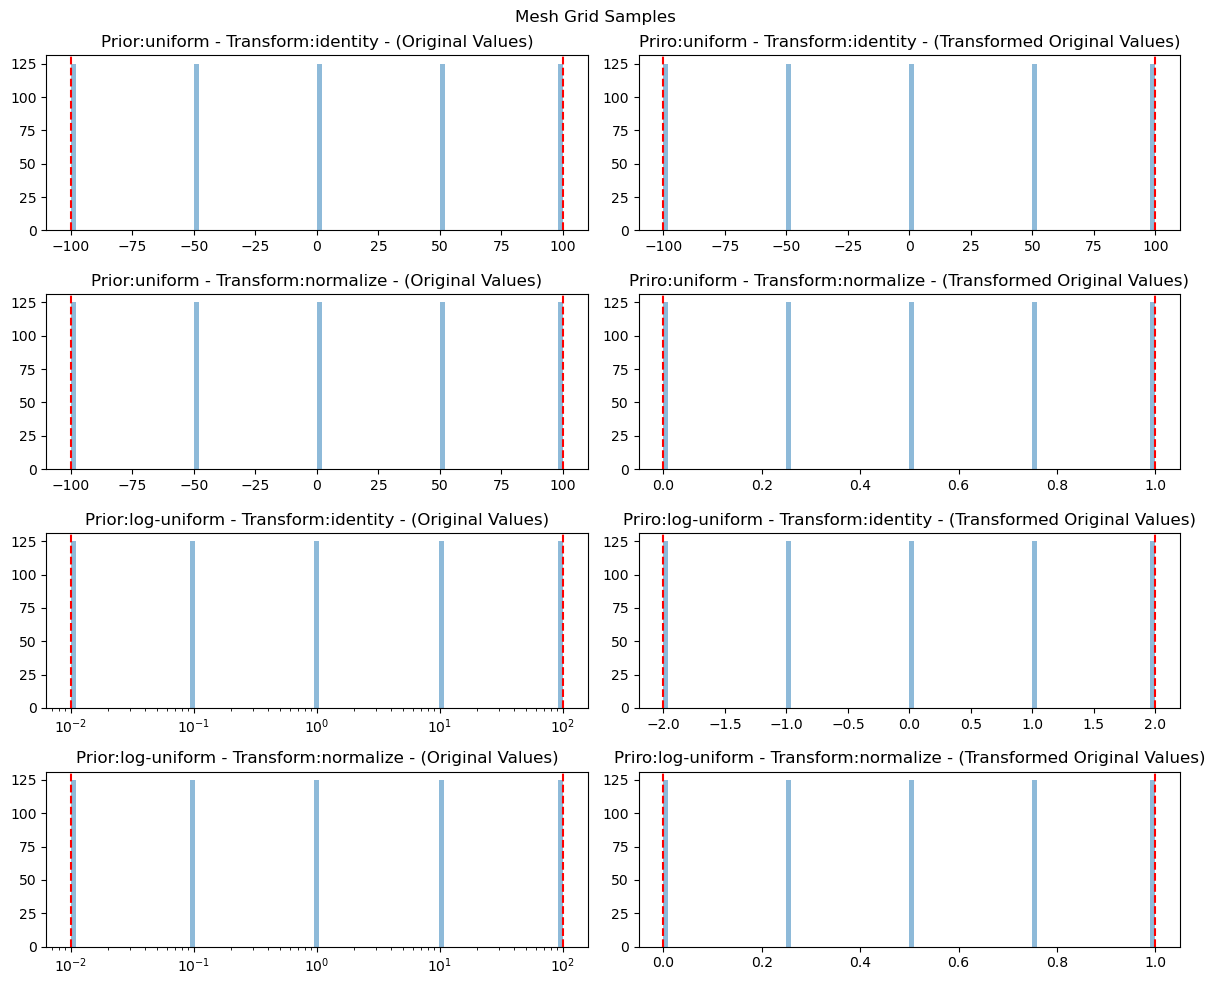

[2025-03-11 11:13:20,393 - INFO - 955837437.hist_samples]: Histogram Samples
[2025-03-11 11:13:20,394 - INFO - 955837437.hist_samples]: Space Names: ['uni-orig', 'uni-norm', 'log-orig', 'log-norm']
[2025-03-11 11:13:20,395 - INFO - 955837437.hist_samples]: [ 4.61e+01 -5.86e+01  2.96e-01  4.86e-02] - Original Samples
[2025-03-11 11:13:20,396 - INFO - 955837437.hist_samples]: [ 4.67e+01  2.55e-02  1.54e-01  1.67e-01] - Normalized Samples


LHS Samples


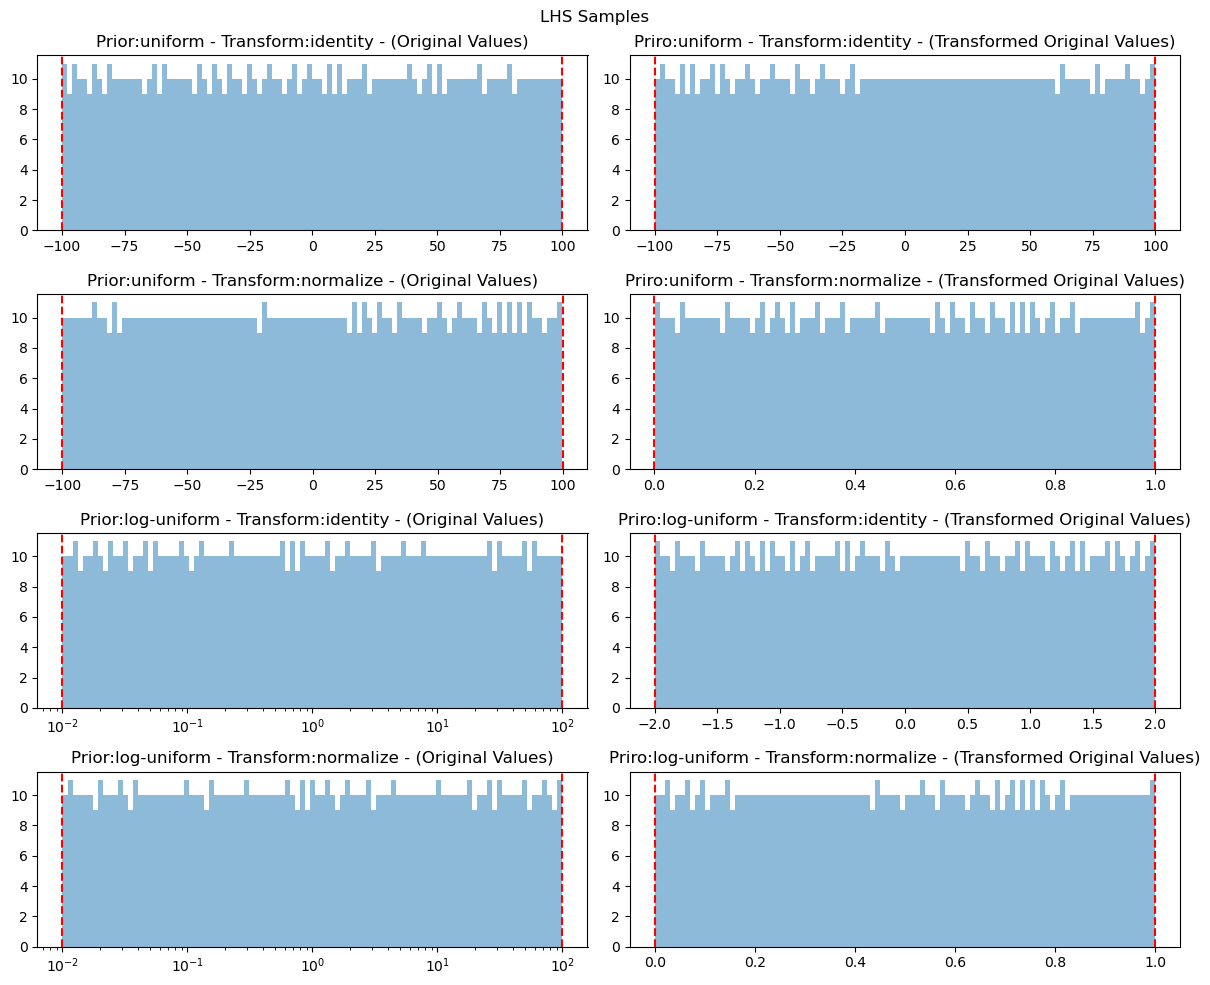

/home/mbo2d/.local/lib/python3.10/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+1000=1000. 
  warnings.warn(
/home/mbo2d/.local/lib/python3.10/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+1000=1000. 
  warnings.warn(
[2025-03-11 11:13:23,520 - INFO - 955837437.hist_samples]: Histogram Samples
[2025-03-11 11:13:23,521 - INFO - 955837437.hist_samples]: Space Names: ['uni-orig', 'uni-norm', 'log-orig', 'log-norm']
[2025-03-11 11:13:23,522 - INFO - 955837437.hist_samples]: [ 4.43e+01  9.53e+01  3.42e-02  2.72e+01] - Original Samples
[2025-03-11 11:13:23,523 - INFO - 955837437.hist_samples]: [-3.22e+01  2.23e-01  1.06e-01  7.27e-01] - Normalized Samples


Sobol Samples


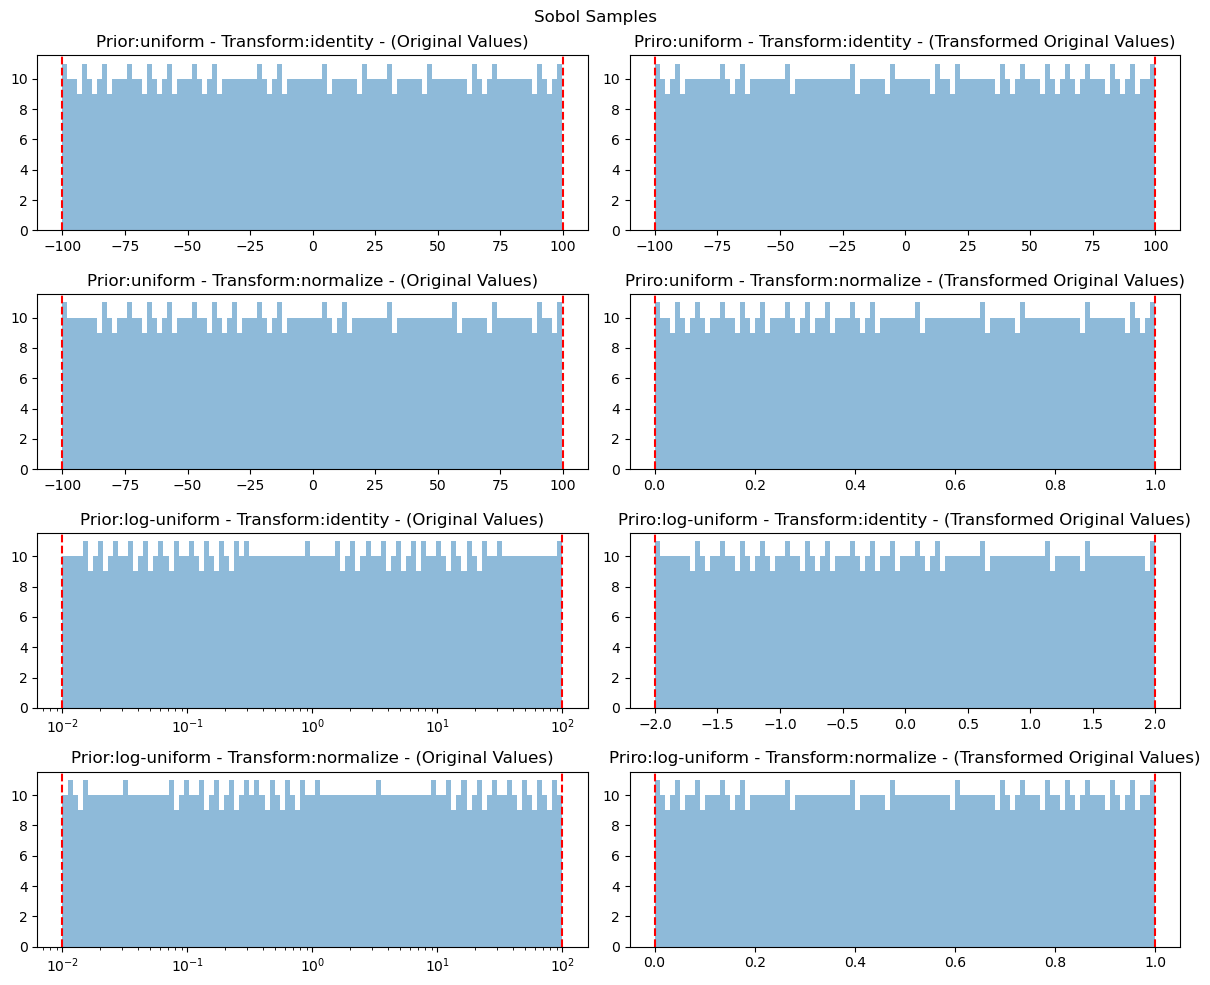

In [3]:
class Space_Manager:
    '''
    Class to manage the space between black-box functions 
    and algorithms that benefit from normalized variables.
    All variables are handled as `Real` for simplicity.
    '''

    def __init__(self, space_info, logger_level=logging.INFO):
        """ Initialize the search space with variable details. """
        self.logger = gu.configure_logging( logger_name = 'Space_Manager', log_level = logger_level )
        self.logger.info(f"Initializing Space Manager")
        self.space_info = space_info  # Assume space info is a list of dictionaries
        self.space = self._create_space()
        self.version = 1  # Initialize versioning for space updates
        self.space_record = {} # for storing space details over multiple versions
        self.space_record[self.version] = self.space_info
        self.logger.info(f"Space Manager Initialized")
    # end of __init__

    def get_space(self):
        return self.space_info
    # end of get_space

    def _create_space(self):
        """Creates and initializes the search space with optional transformations."""

        space = []
        for i,var_info in enumerate(self.space_info):

            var_name = var_info['name']  # Required

            # Extract basic attributes
            bounds = var_info.get('bounds', None)  # Required
            prior = var_info.get('prior', 'uniform')  # Default to uniform, used for sampling
            transform = var_info.get('transform', 'identity')  # Default to identity, used for normalization
            meta = var_info.get('meta', {})  # Meta-information (optional)

            # Most types require bounds
            if bounds is None:
                raise ValueError(f"Bounds are required for variable type: {var_name}")

            # Handle Real variable types with transformation
            if transform in ['normalize', 'identity']:
                # If standard transforms (normalize or identity)
                dimension = Real(bounds[0], bounds[1], prior=prior, name=var_name, transform=transform)

                # generate transformed bounds
                dimension.transformed_bounds_ = [dimension.transform(bounds[0]), dimension.transform(bounds[1])]

            else:
                raise ValueError(f"Unsupported transform type: {transform}")

            # Attach meta-information for reference
            if meta:
                dimension.meta = meta  # Store meta info as an attribute
            else:
                dimension.meta = None

            space.append( dimension )

            # Add everything to the space info
            self.space_info[i]['prior'] = prior
            self.space_info[i]['transform'] = transform
            self.space_info[i]['transformed_bounds'] = dimension.transformed_bounds_

        return space
    # end of _create_space

    def update_space(self, space_info):
        """Update the search space with new bounds, variables or transformations."""
        self.space_info = space_info
        self.space = self._create_space()
        self.version += 1
    # end of update_space

    def transform_points(self, points, inverse=False):
        """
        Transforms points from original space to normalized space or vice-versa.
        points: np.ndarray of shape (n_points, n_dims)        
        """

        # If there's a single point, add a dummy axis to make it a batch of one
        if len(points.shape) == 1:
            points = points.reshape(1, -1)
        
        # iterate over columns
        for i in range(points.shape[1]):

            # Apply transformation
            if inverse:
                points[:, i] = self.space[i].inverse_transform(points[:, i])
            else:
                points[:, i] = self.space[i].transform(points[:, i])
            
        if len(points) == 1:
            return points[0]
        else:
            return points
    # end of transform_points

    def get_random_sample( self, n_samples = 3, space='normalized', shuffle=True ):
        """ Get random samples from the search space. """

        samples = np.zeros((n_samples, len(self.space_info)))
        for i, dim in enumerate(self.space):
            samples[:, i] = dim.rvs(n_samples)
        
        if shuffle:
            np.random.permutation(samples)

        if space == 'normalized':
            return self.transform_points(samples)
        else:        
            return samples
    # end of get_random_sample

    def get_mesh_grid_points( self, n_pts_per_dim = 5, space='normalized', shuffle=True ):
        """ Generate mesh grid points for the search space. """

        # Select values along each dimension
        grids = []
        for dim in self.space:
            if dim.prior == 'uniform':
                grids.append(np.linspace(dim.low, dim.high, num=n_pts_per_dim))
            if dim.prior == 'log-uniform':
                grids.append(np.logspace(np.log10(dim.low), np.log10(dim.high), num=n_pts_per_dim))

        # Generate grid points
        grid_points = np.array(np.meshgrid(*grids)).T.reshape(-1, len(self.space))

        if shuffle:
            np.random.permutation(grid_points)

        if space == 'original':
            return grid_points
        else:
            return self.transform_points(grid_points)
    # end of get_mesh_grid_points
           
    def get_lhs_samples( self, n_samples = 10, space='normalized', shuffle=True ):
        """ Get Latin Hypercube samples from the search space. """

        lhs = Lhs(lhs_type="classic", criterion=None)
        samples = np.array( lhs.generate(self.space, n_samples) )
        
        if shuffle:
            np.random.permutation(samples)

        if space == 'normalized':
            return self.transform_points(samples)
        else:
            return samples
    # end of get_lhs_samples

    def get_sobol_samples(self, n_samples=10, space='normalized', shuffle=True):
        """Get Sobol samples from the search space."""

        sampler = Sobol()
        sobol_samples = np.array(sampler.generate(self.space, n_samples))

        if shuffle:
            np.random.permutation(sobol_samples)

        if space == 'normalized':
            return self.transform_points(sobol_samples)
        else:
            return sobol_samples
    # end of get_sobol_samples

    def save_space_details(self, file_path):
        """Save the dimension details to a JSON file."""
        import json

        json.dump(self.space_info, open(file_path, 'w'), indent=2)
    # end of save_space_details
    
# end of SpaceManager class

def hist_samples( o_samples, n_samples, space_info, manager, title='Histograme Samples' ):

    # Create plots with 4 subpltos
    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(len(space_info), 2, figsize=(12, 10))
    # fig, axs = plt.subplots(len(space_info), 4, figsize=(24, 10))
    
    # set main title
    fig.suptitle(title)

    # Turn off debug logging for matplotlib
    plt.rcParams['figure.max_open_warning'] = 0

    # Check if transform works
    ot_samples = manager.transform_points(np.copy(o_samples))
    nt_samples = manager.transform_points(np.copy(n_samples), inverse=True)

    logger.info("Histogram Samples")
    logger.info(f"Space Names: {[var_info['name'] for var_info in space_info]}")
    logger.info(f"{o_samples[0]} - Original Samples")
    # logger.info(f"{ot_samples[0]} - Transformed Original Samples")
    
    logger.info(f"{n_samples[0]} - Normalized Samples")
    # logger.info(f"{nt_samples[0]} - Transformed Normalized Samples")

    logger.setLevel(logging.INFO)

    for i, var_info in enumerate(space_info):
        var_name = var_info['name']
        # print(f"\nVariable: {var_name}")
        # Add to first subplot
        if var_info['prior'] == 'log-uniform':
            # Bin with log scaling
            axs[i, 0].set_xscale('log')
            axs[i, 0].hist(o_samples[:, i], bins=np.logspace(np.log10(var_info['bounds'][0]), np.log10(var_info['bounds'][1]), 100), alpha=0.5, label='Original')
        
        else:
            axs[i, 0].hist(o_samples[:, i], bins=100, alpha=0.5, label='Original')

        # axs[i, 2].hist(ot_samples[:, i], bins=100, alpha=0.5, label='Transformed Original')
        # axs[i, 3].hist(nt_samples[:, i], bins=100, alpha=0.5, label='Transformed Normalized')

        axs[i, 1].hist(n_samples[:, i], bins=100, alpha=0.5, label='Normalized')
        
        axs[i, 0].set_title(f"Prior:{var_info['prior']} - Transform:{var_info['transform']} - (Original Values)")
        axs[i, 1].set_title(f"Priro:{var_info['prior']} - Transform:{var_info['transform']} - (Transformed Original Values)")

        # Add bounds to the plot
        axs[i, 0].axvline(var_info['bounds'][0], color='r', linestyle='--')
        axs[i, 0].axvline(var_info['bounds'][1], color='r', linestyle='--')

        try:
            axs[i, 1].axvline(manager.space[i].transformed_bounds_[0], color='r', linestyle='--')
            axs[i, 1].axvline(manager.space[i].transformed_bounds_[1], color='r', linestyle='--')
        except:
            pass
    
    # logger.setLevel(logging.DEBUG)
    
    # tight layout
    plt.tight_layout()
    plt.show()


def test_space_manager():
    logger.info(f"Testing Space Manager")

    logger.setLevel(logging.INFO)

    space_transform_test = [
        {'name':'uni-orig', 'type': 'float', 'bounds': [-100, 100], 'prior':'uniform', 'transform':'identity'  }, # Working
        {'name':'uni-norm', 'type': 'float', 'bounds': [-100, 100], 'prior':'uniform', 'transform':'normalize' }, # Working
        {'name':'log-orig', 'type': 'float', 'bounds': [1e-2, 100], 'prior':'log-uniform', 'transform':'identity' }, # Working
        {'name':'log-norm', 'type': 'float', 'bounds': [1e-2, 100], 'prior':'log-uniform', 'transform':'normalize' }, # Working
    ]
    
    print("\nTesting Space Manager with Input Space:")
    for var_info in space_transform_test:
        print(var_info)
    # gu.pp(space_transform_test)
    print('')

    manager = Space_Manager(space_transform_test)

    manager.save_space_details('test_space_details.json')

    n = 1000
    o_samples = manager.get_random_sample(n, space='original') # original samples
    n_samples = manager.get_random_sample(n, space='normalized') # normalized samples
    
    print("Random Samples")
    hist_samples( o_samples, n_samples, space_transform_test, manager, title='Random Samples' )

    if True:

        # Do the same with gridsearch
        o_samples = manager.get_mesh_grid_points(5, space='original') # original samples
        n_samples = manager.get_mesh_grid_points(5, space='normalized') # normalized samples
        print("Grid Samples")
        hist_samples( o_samples, n_samples, space_transform_test, manager, title='Mesh Grid Samples' )

        # Do the same with LHS
        o_samples = manager.get_lhs_samples(n, space='original') # original samples
        n_samples = manager.get_lhs_samples(n, space='normalized') # normalized samples
        print("LHS Samples")
        hist_samples( o_samples, n_samples, space_transform_test, manager, title='LHS Samples' )

        # Do the same with Sobol
        o_samples = manager.get_sobol_samples(n, space='original') # original samples
        n_samples = manager.get_sobol_samples(n, space='normalized') # normalized samples
        print("Sobol Samples")
        hist_samples( o_samples, n_samples, space_transform_test, manager, title='Sobol Samples' )

if buildEnv:
    # Set numpy precision print with arrays as sci format with 3 decimals w space for sign
    np.set_printoptions(precision=3, suppress=True, formatter={'all': lambda x: f'{x: 0.2e}'})
    test_space_manager()

[2025-03-11 11:50:58,385 - INFO - 768877686.<module>]: My Current log level is 'DEBUG'
[2025-03-11 11:50:58,387 - INFO - 768877686.<module>]: Function Logger is at 'INFO'
[2025-03-11 11:50:58,388 - INFO - 768877686.<module>]: Having test module call print log function
[2025-03-11 11:50:58,393 - INFO - parallel_queue_manager._set_local_mode]: Local Manager initialized with 32 workers using local multiprocessing (futures).
[2025-03-11 11:50:58,459 - INFO - parallel_queue_manager.__del__]: Queue Manager Deleted


Creating a new logger for testing the test function
You should see function calls


test print: 2test print: 4test print: 3




[2025-03-11 11:50:59,084 - ERROR - 768877686.testing_logger]: Error: 4
[2025-03-11 11:50:59,085 - ERROR - 768877686.testing_logger]: Error: 2
[2025-03-11 11:50:59,085 - ERROR - 768877686.testing_logger]: Error: 3
[2025-03-11 11:50:59,086 - CRITICAL - 768877686.testing_logger]: Critical: 4
[2025-03-11 11:50:59,086 - CRITICAL - 768877686.testing_logger]: Critical: 2
[2025-03-11 11:50:59,087 - DEBUG - 768877686.testing_logger]: Std Logger Debug: 4
[2025-03-11 11:50:59,087 - CRITICAL - 768877686.testing_logger]: Critical: 3
[2025-03-11 11:50:59,091 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [====================] 3/3 - Queue Complete
[2025-03-11 11:50:59,088 - DEBUG - 768877686.testing_logger]: Std Logger Debug: 2
[2025-03-11 11:50:59,096 - INFO - 768877686.<module>]: Results: [4, 6, 8]
[2025-03-11 11:50:59,097 - INFO - 768877686.testing_logger]: Info: 5
[2025-03-11 11:50:59,089 - DEBUG - 768877686.testing_logger]: Std Logger Debug: 3
[2025-03-11 11:50:

test print: 5
test print: [-3.71e+00]test print: [ 3.36e+00]test print: [-2.60e+00]test print: [-8.87e-01]





[2025-03-11 11:50:59,771 - ERROR - 768877686.testing_logger]: Error: [-2.60e+00]
[2025-03-11 11:50:59,771 - ERROR - 768877686.testing_logger]: Error: [-3.71e+00]
[2025-03-11 11:50:59,771 - ERROR - 768877686.testing_logger]: Error: [-8.87e-01]
[2025-03-11 11:50:59,772 - CRITICAL - 768877686.testing_logger]: Critical: [-2.60e+00]
[2025-03-11 11:50:59,772 - ERROR - 768877686.testing_logger]: Error: [ 3.36e+00]
[2025-03-11 11:50:59,773 - CRITICAL - 768877686.testing_logger]: Critical: [-3.71e+00]
[2025-03-11 11:50:59,780 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [====================] 4/4 - Queue Complete
[2025-03-11 11:50:59,774 - CRITICAL - 768877686.testing_logger]: Critical: [-8.87e-01]
[2025-03-11 11:50:59,774 - DEBUG - 768877686.testing_logger]: Std Logger Debug: [-2.60e+00]
[2025-03-11 11:50:59,774 - DEBUG - 768877686.testing_logger]: Std Logger Debug: [-3.71e+00]
[2025-03-11 11:50:59,785 - INFO - 768877686.test_evaluation_manager]: Testing Eval


Testing Input Space:
{'name': 'uni-orig', 'type': 'float', 'bounds': [-4, 4], 'prior': 'uniform', 'transform': 'identity'}
{'name': 'log-orig', 'type': 'float', 'bounds': [0.01, 4], 'prior': 'log-uniform', 'transform': 'identity'}
{'name': 'uni-norm', 'type': 'float', 'bounds': [-4, 4], 'prior': 'uniform', 'transform': 'normalize'}
{'name': 'log-norm', 'type': 'float', 'bounds': [0.01, 4], 'prior': 'log-uniform', 'transform': 'normalize'}

Test Function: Sum of Squares (sum(x^2))


[2025-03-11 11:51:00,824 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [=============       ] 665/1000
[2025-03-11 11:51:00,948 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [====================] 1000/1000 - Queue Complete
[2025-03-11 11:51:02,052 - INFO - 3759878367.__del__]: Execution Manager Terminated
[2025-03-11 11:51:02,129 - INFO - parallel_queue_manager.__del__]: Queue Manager Deleted
[2025-03-11 11:51:02,811 - INFO - 768877686.__del__]: Execution Manager Terminated
[2025-03-11 11:51:02,874 - INFO - parallel_queue_manager.__del__]: Queue Manager Deleted


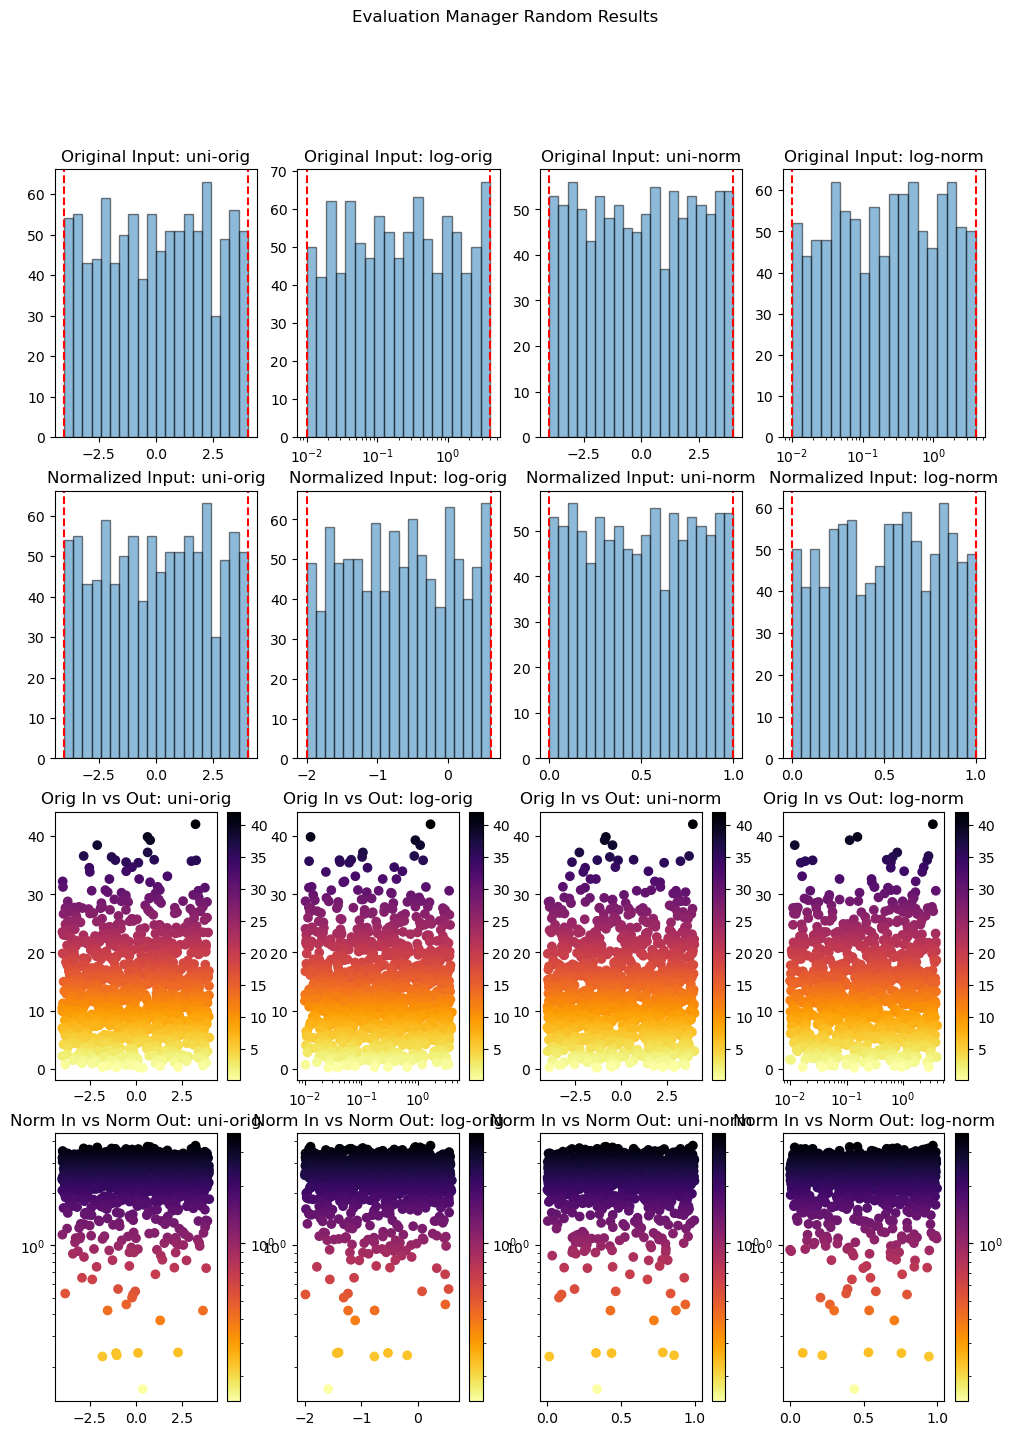

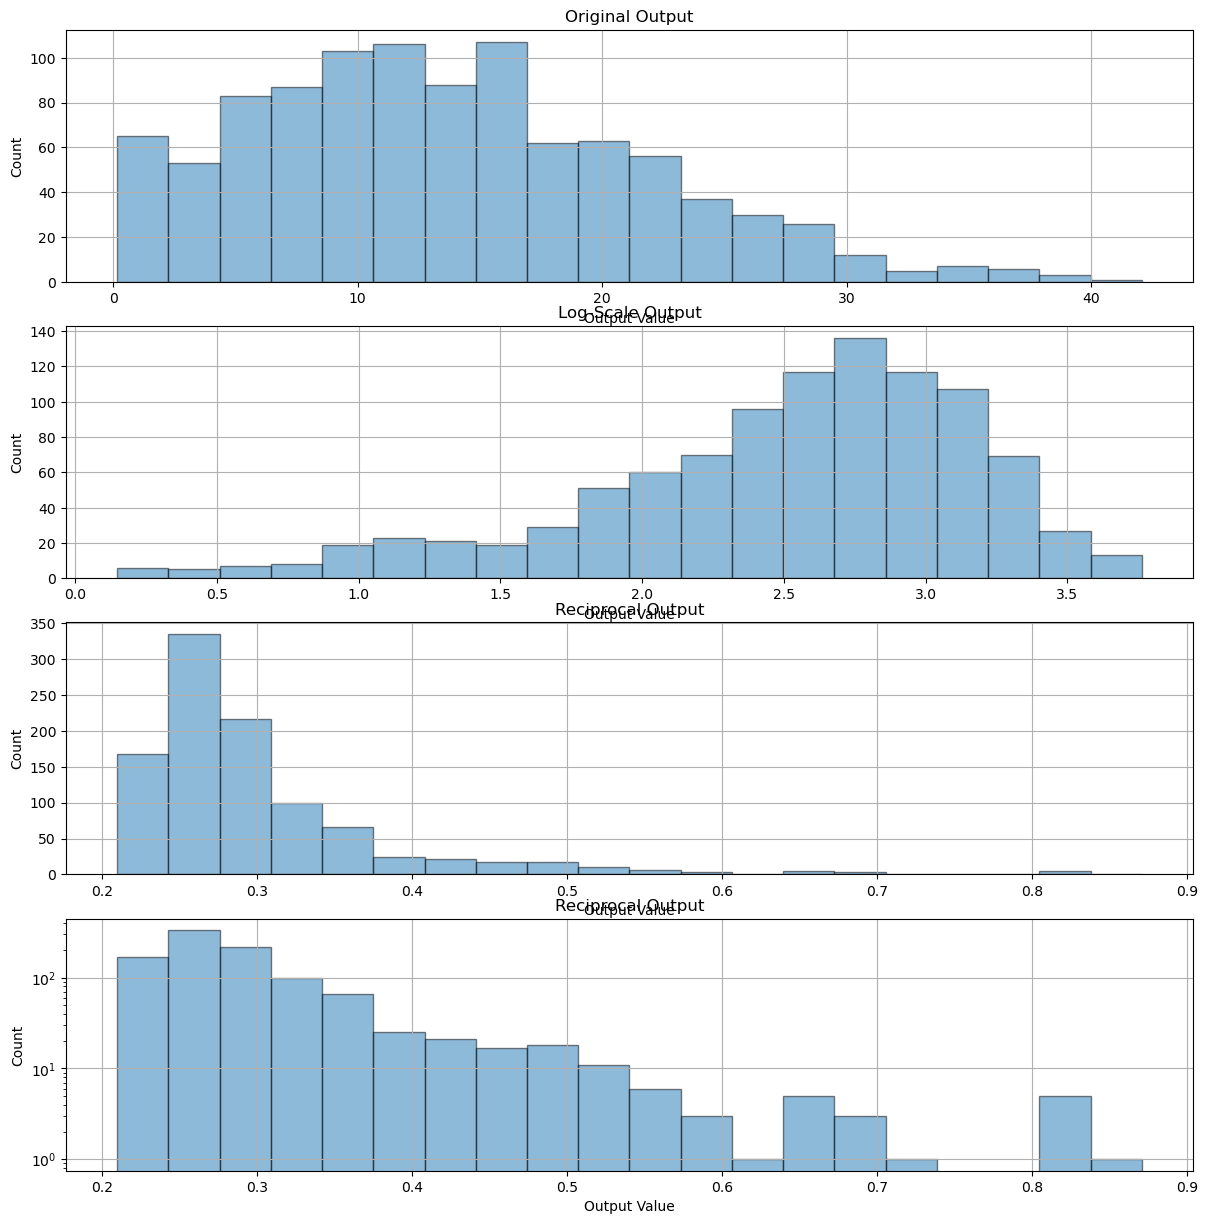

In [31]:
class Execution_Manager:
    """
    Class to manage the execution of black-box functions in parallel.
    Interfaces with the space manager to handle normalized dimensions.
    Also normalizes the final scores if requested.
    Feeds noramlized inputs and ouputs to higher-level optimization algorithms.
    NOTE: This is intended for computationlly expensive functions.
    """

    def __init__( self, space_manager, black_box_function, normalize_output='original',
                 save_results=True, num_outputs=1, exec_log_level=logging.INFO,
                 func_logger = None, func_log_level = logging.WARNING,
                 ):
        
        """Initialize the execution manager with the function to evaluate."""
        self.logger = gu.configure_logging( logger_name='execution_manager', log_level=exec_log_level )
        self.logger.info(f"Initializing Execution Manager")

        self.save_results = save_results
        self.space_manager = space_manager
        self.n_dims = len(space_manager.space_info)
        self.n_out = num_outputs
        self.x = np.zeros((0, self.n_dims)) # Original Inputs
        self.y = np.zeros((0, self.n_out)) # Original Outputs
        self.xn = np.zeros((0, self.n_dims)) # Normalized Inputs
        self.yn = np.zeros((0, self.n_out)) # Normalized Outputs
        self.bad_x = np.zeros((0, self.n_dims)) # Bad Inputs

        # Generate output normalizer function
        self.gen_output_normalizer(normalize_output)

        # Setup Execution Environment for black box function
        self.function = black_box_function
        self.func_logger = func_logger if func_logger is not None else logging.getLogger('')  # Assume function uses root logger if not provided
        self.func_log_level = func_log_level
        self.comm = MPI.COMM_WORLD
        self.rank = self.comm.Get_rank()
        self.size = self.comm.Get_size()

        # Setup Parallel workers to be on standby to process black box function evaluations
        if self.rank != 0:
            self.logger.info(f"Execution Worker on Standby")
            self.queue_manager = qm.Queue_Worker(self.function)
            return
        
        # Else you're the manager. Continue with initialization
        self.queue_manager = qm.Queue_Manager(self.function)

        # Else, you're a manager. Continue with initialization
        self.logger.info(f"Execution Manager Initialized")
        
    # end of __init__

    def __del__(self):
        if self.rank == 0:
            self.queue_manager.terminate_workers()
        self.logger.info(f"Execution Manager Terminated")
    # end of __del__

    def set_function_log_level( self, log_level ):
        """Set the log level for the function logger."""
        self.func_logger.setLevel(log_level)
    # end of set_function_log_level

    def evaluate_function(self, x, space = 'normalized', save_results=None):
        """Evaluate the black-box function for a given list."""
        self.logger.info(f"Evaluating Function: Inputs: {len(x)}")
        self.logger.debug(f"x - {len(x)}: {x[0]}")

        if save_results is None:
            save_results = self.save_results
        
        # Save previous func logger level
        prev_log_level = self.func_logger.level

        # set to new level
        self.func_logger.setLevel(self.func_log_level)

        if space == 'normalized':
            results = self.evaluate_function_normalized(x, save_results)
        elif space == 'original':
            results =  self.evaluate_function_from_original(x, save_results)
               
        # Return to previous level
        self.func_logger.setLevel(prev_log_level)

        return results
    # end of evaluate_function

    def evaluate_function_normalized(self, nx, save_results=None):
        """Evaluate the black-box function for a given list."""

        if save_results is None:
            save_results = self.save_results

        # If x is list, convert to numpy array
        if isinstance(nx, list):
            nx = np.array(nx)

        self.logger.info("Starting Normalized Evaluation of Function")
        self.logger.debug(f"nx.shape{nx.shape} - nx[0]: {nx[0]}")

        # Check if ranges are appropriate
        for i, dim in enumerate(self.space_manager.space):
            min_value = np.amin( nx[:, i] )
            max_value = np.amax( nx[:, i] )
            if  ( ( min_value < dim.transformed_bounds_[0] ) or ( dim.transformed_bounds_[1] < max_value) ):
                logger.error(f"Normalized Input Column {i} is out of bounds: [{min_value:.2e}, {max_value:.2e}] not in [{dim.transformed_bounds_[0]}, {dim.transformed_bounds_[1]}]")
                raise ValueError(f"Input Column {i} is out of bounds: [{min_value:.2e}, {max_value:.2e}] not in [min, max] [{dim.low}, {dim.high}]")
        
        # Inverse transform the normalized inputs to orginal space
        x = np.copy(nx)
        x = self.space_manager.transform_points(np.copy(nx), inverse=True)

        # Verify x has the same shape as nx
        if x.shape != nx.shape:
            x = np.reshape(x, nx.shape)

        self.logger.debug(f" x.shape{x.shape} -  x[0]: {x[0]}")
        
        # Add list to the queue and evaluate
        y_raw = self.queue_manager.evaluate_tasks(x)

        # Loop backwards through returns and remove any None values, as well as corresponding x values
        popped_count = 0
        for i in range( len(y_raw) - 1, -1, -1):
            
            # Check if exception value was given
            if isinstance(y_raw[i], Exception):

                # print exception before removing
                self.logger.warning(f"Exception Returned: '{y_raw[i]}'")
                self.bad_x = np.vstack([self.bad_x, x[i]])
                x = np.delete(x, i, axis=0)
                nx = np.delete(nx, i, axis=0)
                y_raw.pop(i)
                popped_count += 1

            elif isinstance(y_raw[i], type(None)):
                self.bad_x = np.vstack([self.bad_x, x[i]])
                x = np.delete(x, i, axis=0)
                nx = np.delete(nx, i, axis=0)
                y_raw.pop(i)
                popped_count += 1

        if popped_count > 0:
            self.logger.warning(f"Removed {popped_count} of {len(x)+popped_count} inputs due to None/Null")
        
        # Check if all evaluations failed
        if len(x) == 0:
            self.logger.error(f"All Executions failed.  Raising error")
            raise ValueError("All Functions Evaluations Failed")
        
        y = np.array( y_raw )

        # Make sure y is 2D
        if len(y.shape) == 1:
            y = y.reshape(-1, self.n_out)

        self.logger.debug(f" y.shape: {y.shape} -  y[0]: {y[0]}")
        ny = self.output_normalizer(y)

        self.logger.debug(f"ny.shape: {ny.shape} - ny[0] {ny[0]}")

        # add retsults to the results array
        if save_results:
            self.x = np.vstack([self.x, x])
            self.y = np.vstack([self.y, y])
            self.xn = np.vstack([self.xn, nx])
            self.yn = np.vstack([self.yn, ny])

        return ny
    # end of evaluate_function

    def evaluate_function_from_original(self, x, save_results=None):
        """Evaluate the black-box function for a given list."""

        # If save_results is None, use the default
        if save_results is None:
            save_results = self.save_results

        # If tx is list, convert to numpy array
        if isinstance(x, list):
            x = np.array(x)
        self.logger.debug(f"x - {x.shape}: {x[0]}")

        # Add list to the queue and evaluate
        y_raw = self.queue_manager.evaluate_tasks(x)

        # Loop backwards through returns and remove any None values, as well as corresponding x values
        for i in range( len(y_raw) - 1, -1, -1):
            if y_raw[i] is None:
                x = np.delete(x, i, axis=0)
                y_raw.pop(i)
        
        y = np.array( y_raw )
        self.logger.debug(f"y - {y.shape}: {y[0]}")

        if save_results:

            # If 1D, add a dummy axis
            if len(x.shape) == 1:
                x = x.reshape(-1, self.n_dims)
            if len(y.shape) == 1:
                y = y.reshape(-1, self.n_out) 

            self.logger.debug(f"Saving Results: x: {x.shape} y: {y.shape}")
            self.logger.debug(f"Saving to x: {self.x.shape} y: {self.y.shape}")
            self.x = np.vstack([self.x, x])    
            self.y = np.vstack([self.y, y])
            self.logger.debug(f"Stacked Results: x: {self.x.shape} y: {self.y.shape}")

        return y
    # end of evaluate_function

    def get_results( self, last_n = -1, space='normalized' ):
        """Get the results from the execution manager."""

        if space == 'original':
            return( self.x.copy(), self.y.copy() )

        elif space == 'normalized':
            return( self.xn.copy(), self.yn.copy() )
    # end of get_results

    def gen_output_normalizer(self, normalize_output='original'):
        """Create the output normalizer function."""

        # Create output normalization function
        if normalize_output == 'original':
            self.output_normalizer = lambda x: x

        elif normalize_output == 'negate':
            self.output_normalizer = lambda x: -1.0 * x

        elif normalize_output == 'log':
            self.output_normalizer = lambda x: np.log1p(x)

        elif normalize_output == 'reciprocal':
            self.output_normalizer = lambda x: 1.0 / (1.0 + x)

        else:
            self.logger.error(f"Unsupported output normalization: {normalize_output}")
            self.logger.error(f"Accepted values: original, negate, log, reciprocal")
            raise ValueError(f"Unsupported output normalization: {normalize_output}")
    # end of gen_output_normalizer

    def new_output_normalizer(self, new_norm):
        """Change the output normalizer function."""
        self.gen_output_normalizer(new_norm)
        for c in range(self.yn.shape[1]):
            self.yn[:, c] = self.output_normalizer(self.yn[:, c])

    def clear_results(self):
        """Clear the results stored in the manager."""
        self.x = np.zeros((0, self.n_dims))
        self.y = np.zeros((0, self.n_out))
        self.xn = np.zeros((0, self.n_dims))
        self.yn = np.zeros((0, self.n_out))

    def hist_input( self, dim_index = None, dim_name = None, space='original',
                         title=None, external_ax = None, fig_size = None, external_results = None, 
                         max_bins = 20,
                         ):
        

        # If external axis is None, create a new figure
        if external_ax is None:
            fig_size = (12, 10) if fig_size is None else fig_size
            fig, ax = plt.subplots(figsize=fig_size) 
        
        else:
            ax = external_ax
        
        # Get the results
        x, y = self.get_results(space=space) if external_results is None else external_results
        
        if dim_index is None:
            self.logger.error(f"Dimension Name: {dim_name} not found in space info")
            self.logger.error(f"Available Dimension Names: {all_names}")
            raise ValueError("dim_index must be provided")
    
        # Filter to single dimension
        x = x[:, dim_index]
        dim_info = self.space_manager.space_info[dim_index]

        # Get # of bins based on unique values
        n_bins = len(np.unique(x)) if len(np.unique(x)) < max_bins else max_bins
        
        # Use logarithmic bins if the dimension is log-uniform
        if dim_info['prior'] == 'log-uniform' and space == 'original':
            ax.hist(x, bins=np.logspace(np.log10(dim_info['bounds'][0]), np.log10(dim_info['bounds'][1]), n_bins), alpha=0.5, edgecolor='black')
            ax.set_xscale('log')
        else:
            ax.hist(x, bins=n_bins, alpha=0.5, edgecolor='black')
        
        # Set title
        if title is None:
            title = f"Histogram of {dim_info['name']} ({space})"

        # Add bounds
        
        # Add bounds to the plot
        if space == 'original':
            ax.axvline(dim_info['bounds'][0], color='r', linestyle='--')
            ax.axvline(dim_info['bounds'][1], color='r', linestyle='--')

        else:
            ax.axvline(self.space_manager.space[dim_index].transformed_bounds_[0], color='r', linestyle='--')
            ax.axvline(self.space_manager.space[dim_index].transformed_bounds_[1], color='r', linestyle='--')
        ax.set_title(title)
        
    def hist_output(self, space='original', title=None, external_ax = None, max_bins = 20, y_idx = 0,
                     fig_size = None, external_results = None, log_x = False, log_y=False, reverse_color=False):
        
        # Histogram output values

        # If external axis is None, create a new figure
        if external_ax is None:
            fig_size = (12, 10) if fig_size is None else fig_size
            fig, ax = plt.subplots(figsize=fig_size)
        
        else:
            ax = external_ax

        # Get the results
        x, y = self.get_results(space=space) if external_results is None else external_results

        # Get the output values, final column
        y = y[:, y_idx]

        # Get # of bins based on unique values or length or default
        n_bins = len(np.unique(y)) if len(np.unique(y)) < max_bins else max_bins

        # Use logarithmic bins if log scale requested
        if log_x:
            ax.hist(y, bins=np.logspace(np.log10(np.min(y)), np.log10(np.max(y)), n_bins), alpha=0.5, edgecolor='black')
            ax.set_xscale('log')
        else:
            ax.hist(y, bins=n_bins, alpha=0.5, edgecolor='black')
        
        if log_y:
            ax.set_yscale('log')
        
        # Set title
        if title is None:
            title = f"{space} Output Values {y_idx}"
        
        ax.set_title(title)
        ax.set_xlabel('Output Value')
        ax.set_ylabel('Count')
        ax.grid(True)

    def scatter_input( self, dim_index = None, dim_name = None, space='original', title = None, y_idx = 0,
                                   external_ax = None, fig_size = None, external_results = None, output_log_scale = False, reverse_color=False):
        
        """Scatter plot of input dimension vs output values."""
        # If external axis is None, create a new figure
        if external_ax is None:
            fig_size = (6, 6) if fig_size is None else fig_size
            fig, ax = plt.subplots(figsize=fig_size)
        else:
            ax = external_ax

        # Get the results
        x,y = self.get_results(space=space) if external_results is None else external_results
        self.logger.debug(f"Scatter Plot: x: {x.shape} y: {y.shape}")

        # Reverse sort and filter to desired output
        sorted_idx = np.argsort(y[:, y_idx])
        self.logger.debug(f"Presorted Y: {y.shape}")
        y = y[sorted_idx[::-1]]
        self.logger.debug(f"PreCol Y: {y.shape}")
        y = y[:, y_idx]

        # Filter to desired dimension
        x = x[:, dim_index]

        self.logger.debug(f"Scatter Plot: x: {x.shape} y: {y.shape}")
        self.logger.debug(f"NaNs in y: {np.isnan(y).sum()}")
        self.logger.debug(f"Infs in y: { np.isinf(y).sum()}")

        # Scatter plot
        color = 'inferno_r' if reverse_color else 'inferno'
        if output_log_scale:
            sc = ax.scatter(x, y, c=y, norm=mcolors.LogNorm(vmin=np.min(y), vmax=np.max(y)), cmap=color, alpha=1)
        else:
            sc = ax.scatter(x, y, c=y, cmap=color, alpha=1)

        # add color barimport numpy as np


        cbar = plt.colorbar(sc)

        # Set x scale
        if self.space_manager.space_info[dim_index]['prior'] == 'log-uniform' and space == 'original':
            ax.set_xscale('log')

        # Log scale y if requested
        if output_log_scale:
            ax.set_yscale('log')
        
        # Set title
        if title is None:
            title = f"{space} {self.space_manager.space_info[dim_index]['name']} vs Output {plot_y_idx}"
        ax.set_title(title)
    # end of scatter_input_with_results

def test_evaluation_manager():

    logger.info(f"Testing Evaluation Manager")

    test_space = [
        {'name':'uni-orig', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'identity'  }, # Working
        {'name':'log-orig', 'type': 'float', 'bounds': [.01, 4], 'prior':'log-uniform', 'transform':'identity' }, # Working
        {'name':'uni-norm', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'normalize' }, # Working
        {'name':'log-norm', 'type': 'float', 'bounds': [.01, 4], 'prior':'log-uniform', 'transform':'normalize' }, # Working
    ]

    print("\nTesting Input Space:")
    for var_info in test_space:
        print(var_info)
    space_manager = Space_Manager(test_space)

    test_function = lambda x: np.sum(x**2)
    print("\nTest Function: Sum of Squares (sum(x^2))")
    
    exec_manager = Execution_Manager(space_manager, black_box_function=test_function, normalize_output='log')

    # Validate the evaluation manager inputs/outputs are working correctly
    n = 1000
    n_samples = space_manager.get_random_sample(n,) # Remeber, default is normalized
    n_outputs = exec_manager.evaluate_function(n_samples)

    # Create subplot for each dimension
    fig, axs = plt.subplots(4, 4, figsize=(12, 16))

    # Set main title
    fig.suptitle("Evaluation Manager Random Results")

    # Histogram of inputs and outputs
    for i, dim_info in enumerate(space_manager.space_info):
        # inputs
        exec_manager.hist_input(dim_index=i, space='original', external_ax=axs[0,i], title=f"Original Input: {dim_info['name']}")
        exec_manager.hist_input(dim_index=i, space='normalized', external_ax=axs[1,i], title=f"Normalized Input: {dim_info['name']}",)
        exec_manager.scatter_input(dim_index=i, space='original', external_ax=axs[2,i], title=f"Orig In vs Out: {dim_info['name']}", reverse_color=True)
        exec_manager.scatter_input(dim_index=i, space='normalized', external_ax=axs[3,i], title=f"Norm In vs Norm Out: {dim_info['name']}", output_log_scale=True, reverse_color=True)


    # Create subplot for each dimension
    # plt.clf()
    fig, axs = plt.subplots(4, figsize=(12, 12))
    plt.tight_layout()

    # Histogram of outputs
    exec_manager.hist_output(space='original', external_ax=axs[0,], title="Original Output", reverse_color=True)
    exec_manager.hist_output(space='normalized', external_ax=axs[1,], title="Log-Scale Output", reverse_color=True)

    # New Normalized Output
    exec_manager.new_output_normalizer('reciprocal')  # Reciprocal normalization (bounded between 0 and 1)
    exec_manager.hist_output(space='normalized', external_ax=axs[2], title="Reciprocal Output", reverse_color=False)
    exec_manager.hist_output(space='normalized', external_ax=axs[3], title="Reciprocal Output", reverse_color=False, log_y=True)

    if False:
        # Let's stress test the evaluation manager, verify parallelism is working
        n = 10000
        print("\nRunning 10000 samples as a stress test")
        n_samples = space_manager.get_random_sample(n, space='normalized') # normalized samples
        n_outputs = exec_manager.evaluate_function(n_samples)

if buildEnv:
    reload(qm)

    # Set current logger
    logger.setLevel(logging.DEBUG)

    # Create test logger
    test_logger = gu.configure_logging( logger_name='test_logger', log_level=logging.INFO)

    # Test having multiple loggers
    def testing_logger( x ):
        print(f"test print: {x}")
        test_logger.debug(f"Debug: {x}")
        test_logger.info(f"Info: {x}")
        test_logger.warning(f"Warning: {x}")
        test_logger.error(f"Error: {x}")
        test_logger.critical(f"Critical: {x}")
        logger.debug(f"Std Logger Debug: {x}")
        # raise TypeError("Testing Error")
        return 2*x
    
    logger.info(f"My Current log level is '{logging.getLevelName(logger.level)}'")
    logger.info(f"Function Logger is at '{logging.getLevelName(test_logger.level)}'")
    logger.info(f"Having test module call print log function")
    # testing_logger(1)

    # Note, even though the main logger is debug, the individual logger only printed INFO, which I defined it to.  


    # Most of my modules load at log level by default. 
    print("Creating a new logger for testing the test function")

    test_queue = qm.Queue_Manager( in_function=testing_logger, # give function to eval
                                   function_logger = test_logger, # Root logger. Most functions use root unless defined.
                                   function_log_level=logging.ERROR, # Function print level,
                                   queue_log_level=logging.DEBUG, # Queue print level
                                   )

    print("You should see function calls")
    results = test_queue.evaluate_tasks( [2, 3, 4] )

    logger.info(f"Results: {results}")


    # Now let's verify I didn't override the test logger
    testing_logger(5)

    
    # raise ValueError("Testing Error") 
    test_space = [
        {'name':'uni-orig', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'identity'  }, # Working
    ]

    space_manager = Space_Manager(test_space)

    # Let's test the exec manager
    exec_manager = Execution_Manager( space_manager, testing_logger, func_logger=test_logger, func_log_level=logging.ERROR,  )
    x_test = space_manager.get_random_sample( 4 )

    exec_manager.evaluate_function( x_test )

    test_evaluation_manager()


# Genetic Algorithm


In [39]:
import pygad

class PYGAD_Manager:
    """
    Class to manage the PYGAD optimizer.
    """
    """Initialize the PYGAD optimizer with the function to evaluate.
    ga_config = {
        "num_generations": 100,  # Number of generations to run the GA.
        "num_parents_mating": 4,  # Number of solutions to be selected as parents.
        "sol_per_pop": 10,  # Number of solutions per population.

        "num_genes": 5  # Number of genes in each solution.
        "gene_space": None,  # Restrict gene values to specific ranges or discrete sets.
        "gene_type": float,  # Data type of the genes. Can be float, int, or a list of types.

        "fitness_func": None,  # User-defined fitness function to evaluate solutions.
        "initial_population": None,  # User-defined initial population. If None, GA initializes randomly.
        "stop_criteria": None,  # Criteria to stop the evolution early (e.g., "reach_40", "saturate_7").
        "random_seed": None,  # Set random seed for reproducibility.
        "logger": None  # Logger for capturing outputs.

        "keep_elitism": 1,  # Number of top solutions to keep in the next generation.
        "parent_selection_type": "sus",  # Parent selection strategy 
            # Balanced:['rank', 'sus', 'tournament']
            # Fast/Risky:['sss', 'rws']
            # Exploration: ['random']

        "crossover_type": "single_point",  # Crossover strategy.
            # Lumps genes together: ['single_point', 'two_points'] 
            # High diversity/random mixing: ['uniform', 'scattered']
            # Note, lumping degenerate genes can help.  Consider custom one later
        
        "mutation_probability": [0.1, 0.5]  # [Low, High] Probability for best/worst solutions in adaptive mutation.
        "random_mutation_min_val": -0.1,  # Minimum value for random mutation.
        "random_mutation_max_val":  0.1,  # Maximum value for random mutation.
        "mutation_type": "adaptive",  # Mutation strategy.
            # Simple/Explorative: ['random', 'scramble']
            # Order-focused: ['swap', 'inversion']
            # Smart/Adaptive: ['adaptive']
    }

    pygad_callbacks = {
        "on_start": {
            "description": "Called once before the genetic algorithm starts.",
            "parameters": ["ga_instance"]  # If method: ["ga_instance", "self"]
        },
        "on_fitness": {
            "description": "Called after calculating the fitness values of all solutions.",
            "parameters": ["fitness_values", "ga_instance"]  # If method: ["fitness_values", "ga_instance", "self"]
        },
        "on_parents": {
            "description": "Called after selecting parents for mating.",
            "parameters": ["parents", "ga_instance"]  # If method: ["parents", "ga_instance", "self"]
        },
        "on_crossover": {
            "description": "Called each time the crossover operation is applied.",
            "parameters": ["ga_instance", "offspring"]
        },
        "on_mutation": {
            "description": "Called each time the mutation operation is applied.",
            "parameters": ["ga_instance", "mutated_offspring"]
        },
        "on_generation": {
            "description": "Called after each generation. Returning 'stop' halts the run.",
            "parameters": ["ga_instance"]
        },
        "on_stop": {
            "description": "Called once before the algorithm stops or after the last generation.",
            "parameters": ["ga_instance", "last_gen_fitness"]
        }
    }

    """

    def __init__( self, 
                 ga_config: dict, 
                 input_space: list = None,
                 space_manager: Space_Manager = None, 
                 black_box_function: callable = None,
                 execution_manager: Execution_Manager = None,
                 log_level = logging.INFO
                 ):
        
        # Set logger
        self.logger = gu.configure_logging( logger_name='pygad_manager', log_level=log_level )
        self.logger.info(f"Initializing PYGAD Manager")
        self.logger.debug(f"GA Config: {ga_config}")
        
        # Save the GA config, (Must be given)
        self.ga_config = ga_config
        self.ga_config['logger'] = self.logger
        
        # Save Space manager    
        if space_manager is not None:
            self.space_manager = space_manager
            self.input_space = space_manager.space_info
        
        # Generate Space Manager
        elif input_space is not None:
            self.space_manager = Space_Manager(input_space)
            self.input_space = self.space_manager.space_info

        # Else, raise error
        else:
            raise ValueError("Either input_space or space_manager must be provided.")
    
        # Set the number of inputs and outputs
        self.n_input = len( self.input_space )
        self.ga_config['num_genes'] = self.n_input

        # hard set bounds based on normalized space
        self.ga_config['gene_space'] = []
        for i in range(self.n_input):
            self.ga_config['gene_space'].append( {'low':self.space_manager.space[i].transformed_bounds_[0], 'high':self.space_manager.space[i].transformed_bounds_[1]} )

        # Log input space
        self.logger.info(f"Space Input: {self.n_input}")
        for i, dim in enumerate(self.input_space):
            self.logger.debug(f"Input {i}: {dim}")
        
        # Check if execution manager is provided
        if execution_manager is not None:
            self.execution_manager = execution_manager
        
        # If given black box function, create default execution manager
        elif black_box_function is not None:
            self.execution_manager = Execution_Manager(self.space_manager, black_box_function=black_box_function, normalize_output='original', exec_log_level=log_level)

        # Else, raise error
        else:
            raise ValueError("Either execution_manager or black_box_function must be provided.")
        
        # Set exec variables
        self.n_output = self.execution_manager.n_out

        # Set place holder function
        def placeholder_function( ga_instance, x, x_idx ):
            self.logger.critical(f"WRONG FUNCTION")
            raise RuntimeError("Thus function is a placeholder and should never be called.")
            return 0.0

        # This class will be in charge of executing the function and evaluating the population fitness
        self.ga_config['fitness_func'] = placeholder_function

        # No initial population..? Let's use a known good one for higher dimensions
        if self.ga_config.get('initial_population',None) is None:
            self.logger.info(f"Creating Initial Population")
            self.ga_config['initial_population'] = self.space_manager.get_lhs_samples(self.ga_config['sol_per_pop'], space='normalized')

        # Check for settings that will conflict with current setup
        if self.ga_config.get('mutation_type', None) == 'adaptive':
            self.logger.warning(f"Adaptive Mutation is not yet supported.  Setting to random")
            self.ga_config['mutation_type'] = 'random'
            self.ga_config['mutation_probability'] = 0.25

        ##### pyGAD Initialization #####s
        setattr(pygad.GA, "cal_pop_fitness", _custom_cal_pop_fitness)  # Override pyGAD's calculate population fitness for custom fitness evaluation
        setattr(pygad.GA, "custom_parallel_evaluation_function", self.execution_manager.evaluate_function)  # Add access to my parallel evaluation queue
        self.gad = pygad.GA( **self.ga_config )
        self.logger.info( f"Optimization Manager Initialized" )

    # end __init__

    def _custom_crossover_mask(self, parents, offspring_size):
        """Placeholder: custom crossover function to mask certain genes together """
        pass
    
# The following is copied from the pygad github: https://github.com/ahmedfgad/GeneticAlgorithmPython/blob/master/pygad/pygad.py
# I will modify it to use my execution manager for fitness evaluations of the population
import numpy
from pygad import GA
def _custom_cal_pop_fitness( self, ):
    
    """
    Calculating the fitness values of batches of solutions in the current population. 
    It returns:
        -fitness: An array of the calculated fitness values.
    """
    try:
        if self.valid_parameters == False:
            raise Exception("ERROR calling the cal_pop_fitness() method: \nPlease check the parameters passed while creating an instance of the GA class.\n")

        # 'last_generation_parents_as_list' is the list version of 'self.last_generation_parents'
        # It is used to return the parent index using the 'in' membership operator of Python lists. This is much faster than using 'numpy.where()'.
        if self.last_generation_parents is not None:
            last_generation_parents_as_list = self.last_generation_parents.tolist()

        # 'last_generation_elitism_as_list' is the list version of 'self.last_generation_elitism'
        # It is used to return the elitism index using the 'in' membership operator of Python lists. This is much faster than using 'numpy.where()'.
        if self.last_generation_elitism is not None:
            last_generation_elitism_as_list = self.last_generation_elitism.tolist()

        pop_fitness = ["undefined"] * len(self.population)
        pop_to_eval = []
        idx_to_eval = []

        # Calculating the fitness value of each solution in the current population.
        for sol_idx, sol in enumerate(self.population):
            # Check if the `save_solutions` parameter is `True` and whether the solution already exists in the `solutions` list. If so, use its fitness rather than calculating it again.
            # The functions numpy.any()/numpy.all()/numpy.where()/numpy.equal() are very slow.
            # So, list membership operator 'in' is used to check if the solution exists in the 'self.solutions' list.
            # Make sure that both the solution and 'self.solutions' are of type 'list' not 'numpy.ndarray'.
            # if (self.save_solutions) and (len(self.solutions) > 0) and (numpy.any(numpy.all(self.solutions == numpy.array(sol), axis=1)))
            # if (self.save_solutions) and (len(self.solutions) > 0) and (numpy.any(numpy.all(numpy.equal(self.solutions, numpy.array(sol)), axis=1)))

            # Make sure self.best_solutions is a list of lists before proceeding.
            # Because the second condition expects that best_solutions is a list of lists.
            if type(self.best_solutions) is numpy.ndarray:
                self.best_solutions = self.best_solutions.tolist()

            if (self.save_solutions) and (len(self.solutions) > 0) and (list(sol) in self.solutions):
                solution_idx = self.solutions.index(list(sol))
                fitness = self.solutions_fitness[solution_idx]

            elif (self.save_best_solutions) and (len(self.best_solutions) > 0) and (list(sol) in self.best_solutions):
                solution_idx = self.best_solutions.index(list(sol))
                fitness = self.best_solutions_fitness[solution_idx]

            elif (self.keep_elitism > 0) and (self.last_generation_elitism is not None) and (len(self.last_generation_elitism) > 0) and (list(sol) in last_generation_elitism_as_list):
                # Return the index of the elitism from the elitism array 'self.last_generation_elitism'.
                # This is not its index within the population. It is just its index in the 'self.last_generation_elitism' array.
                elitism_idx = last_generation_elitism_as_list.index(list(sol))
                # Use the returned elitism index to return its index in the last population.
                elitism_idx = self.last_generation_elitism_indices[elitism_idx]
                # Use the elitism's index to return its pre-calculated fitness value.
                fitness = self.previous_generation_fitness[elitism_idx]

            # If the solutions are not saved (i.e. `save_solutions=False`), check if this solution is a parent from the previous generation and its fitness value is already calculated. If so, use the fitness value instead of calling the fitness function.
            # We cannot use the `numpy.where()` function directly because it does not support the `axis` parameter. This is why the `numpy.all()` function is used to match the solutions on axis=1.
            # elif (self.last_generation_parents is not None) and len(numpy.where(numpy.all(self.last_generation_parents == sol, axis=1))[0] > 0):
            elif ((self.keep_parents == -1) or (self.keep_parents > 0)) and (self.last_generation_parents is not None) and (len(self.last_generation_parents) > 0) and (list(sol) in last_generation_parents_as_list):
                # Index of the parent in the 'self.last_generation_parents' array.
                # This is not its index within the population. It is just its index in the 'self.last_generation_parents' array.
                # parent_idx = numpy.where(numpy.all(self.last_generation_parents == sol, axis=1))[0][0]
                parent_idx = last_generation_parents_as_list.index(list(sol))
                # Use the returned parent index to return its index in the last population.
                parent_idx = self.last_generation_parents_indices[parent_idx]
                # Use the parent's index to return its pre-calculated fitness value.
                fitness = self.previous_generation_fitness[parent_idx]
            else:
                # Place holder before evaluation
                fitness = None

                # Add solution to list for later evaluation
                pop_to_eval.append( sol )
                idx_to_eval.append( sol_idx )

            # This is only executed if the fitness value was already calculated.
            pop_fitness[sol_idx] = fitness

        # End acculating existing fitness and seperating new evaluations
        
        # Evaluate the population that needs evaluating
        if len(pop_to_eval) > 0:
            self.logger.debug(f"Population to evaluate: {len(pop_to_eval)}\n{pop_to_eval[:2]}\n...\n{pop_to_eval[-2:]}")

            new_fitness_scores = self.custom_parallel_evaluation_function(pop_to_eval)

            self.logger.debug(f"Returned Fitness Scores: {len(new_fitness_scores)}\n{new_fitness_scores[:2]}\n...\n{new_fitness_scores[-2:]}")

            # Verify they're the same size 
            if len(new_fitness_scores) != len(pop_to_eval):

                raise ValueError("All Functions Evaluations Failed")
            
            # Store the new fitness scores
            for i, idx in enumerate(idx_to_eval):

                fitness = new_fitness_scores[i]

                if type(fitness) in GA.supported_int_float_types:
                    # The fitness function returns a single numeric value.
                    # This is a single-objective optimization problem.
                    pass
                elif type(fitness) in [list, tuple, numpy.ndarray]:
                    # The fitness function returns a list/tuple/numpy.ndarray.
                    # This is a multi-objective optimization problem.
                    pass
                else:
                    raise ValueError(f"The fitness function should return a number or an iterable (list, tuple, or numpy.ndarray) but the value {fitness} of type {type(fitness)} found.")

                pop_fitness[idx] = fitness

        pop_fitness = numpy.array(pop_fitness)

    except Exception as ex:
        self.logger.exception(ex)
        # sys.exit(-1)
        raise ex
    return pop_fitness

if buildEnv:

    # logger.setLevel(logging.DEBUG)
    logger.info(f"Testing GA")

    #####   SPACE   ######
    test_space = [
        {'name':'uni-orig', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'identity'  },
        {'name':'log-orig', 'type': 'float', 'bounds': [.01, 4], 'prior':'log-uniform', 'transform':'identity' },
        {'name':'uni-norm', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'normalize' },
        {'name':'log-norm', 'type': 'float', 'bounds': [.01, 4], 'prior':'log-uniform', 'transform':'normalize' },
    ]

    #####   Function   ######
    def good_function(x):
        # logger.critical(f"GOOD FUNCTION")
        return 1 / ( 1+ np.sum(x**2))

    #####   GA MANAGER   ######
    ga_config = {
        "num_generations": 25,      # Number of generations to run the GA.
        "num_parents_mating": 2,  # Number of solutions to be selected as parents.
        "sol_per_pop": 100,        # Number of solutions per population.
        "gene_type": float,        # Data type of the genes. Can be float, int, or a list of types.
        "random_seed": 0,       # Set random seed for reproducibility.
        "keep_elitism": 1,         # Number of top solutions to keep in the next generation.
        "parent_selection_type": "sus",   # Parent selection strategy 
        "crossover_type": "uniform", # Crossover strategy.        
        "mutation_probability": 0.5,      # Probability of mutating a gene.
        "random_mutation_min_val": -0.1,  # Minimum value for random mutation.
        "random_mutation_max_val":  0.1,  # Maximum value for random mutation.
    }

    my_ga = PYGAD_Manager( ga_config, input_space=test_space, black_box_function=good_function, log_level=logging.INFO )

    my_ga.gad.run()
    print("Done")

[2025-03-11 11:55:06,521 - INFO - 3283643627.<module>]: Testing GA
[2025-03-11 11:55:06,523 - INFO - 3283643627.__init__]: Initializing PYGAD Manager
[2025-03-11 11:55:06,525 - INFO - 955837437.__init__]: Initializing Space Manager
[2025-03-11 11:55:06,533 - INFO - 955837437.__init__]: Space Manager Initialized
[2025-03-11 11:55:06,535 - INFO - 3283643627.__init__]: Space Input: 4
[2025-03-11 11:55:06,536 - INFO - 768877686.__init__]: Initializing Execution Manager
[2025-03-11 11:55:06,540 - INFO - parallel_queue_manager._set_local_mode]: Local Manager initialized with 32 workers using local multiprocessing (futures).
[2025-03-11 11:55:06,541 - INFO - 768877686.__init__]: Execution Manager Initialized
[2025-03-11 11:55:06,542 - INFO - 3283643627.__init__]: Creating Initial Population
[2025-03-11 11:55:06,562 - INFO - 3283643627.__init__]: Optimization Manager Initialized
[2025-03-11 11:55:06,564 - INFO - 768877686.evaluate_function]: Evaluating Function: Inputs: 100
[2025-03-11 11:55:0

[2025-03-11 11:55:07,317 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [====================] 100/100 - Queue Complete
[2025-03-11 11:55:07,913 - INFO - 768877686.evaluate_function]: Evaluating Function: Inputs: 97
[2025-03-11 11:55:07,915 - INFO - 768877686.evaluate_function_normalized]: Starting Normalized Evaluation of Function
[2025-03-11 11:55:07,972 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [====================] 97/97 - Queue Complete
[2025-03-11 11:55:08,359 - INFO - 768877686.evaluate_function]: Evaluating Function: Inputs: 96
[2025-03-11 11:55:08,361 - INFO - 768877686.evaluate_function_normalized]: Starting Normalized Evaluation of Function
[2025-03-11 11:55:08,415 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [====================] 96/96 - Queue Complete
[2025-03-11 11:55:08,903 - INFO - 768877686.evaluate_function]: Evaluating Function: Inputs: 97
[2025-03-11 11:55:08,

Done


In [ ]:


def _on_parents(self, ga_instance, parents):
        """Custom on_parents function for the GA."""
        self.logger.info("On Parents")
        self.logger.debug(f"Parents: {type(parents)}")
        # self.logger.debug(f"Parents: \n{parents[:2]}\n...\n{parents[-2:]}")
        self.logger.info("On Parents Complete")
    # end of _on_parents

def custom_run(self, generations=None):
        """Custom run method for the GA."""
        self.logger.info("Custom Run")
        
        if generations is None:
            generations = self.ga_config['num_generations']
        
        self.logger.info(f"Running GA for {generations} generations")
        self._custom_fitness()

        self.gad.on_parents( self.gad, self.gad.last_generation_parents )
    

if buildEnv:

    ga_config['sol_per_pop'] = 10

    # Create new GA
    my_ga = PYGAD_Manager( ga_config, input_space=test_space, black_box_function=good_function, logger=debug_logger )

    # my_ga.custom_run()
    my_ga.gad.run()
        

[2025-03-11 11:13:36,472 - INFO - 470521267.__init__]: Initializing PYGAD Manager
[2025-03-11 11:13:36,474 - DEBUG - 470521267.__init__]: GA Config: {'num_generations': 1, 'num_parents_mating': 2, 'sol_per_pop': 10, 'gene_type': <class 'float'>, 'random_seed': 0, 'keep_elitism': 1, 'parent_selection_type': 'sus', 'crossover_type': 'uniform', 'mutation_probability': [0.7, 0.4], 'random_mutation_min_val': -0.1, 'random_mutation_max_val': 0.1, 'mutation_type': 'adaptive', 'logger': <Logger pygad_manager (DEBUG)>, 'num_genes': 4, 'gene_space': [{'low': -4, 'high': 4}, {'low': -2.0, 'high': 0.6020599913279624}, {'low': 0.0, 'high': 1.0}, {'low': 0.0, 'high': 1.0}], 'fitness_func': <function PYGAD_Manager.__init__.<locals>.placeholder_function at 0x7f3ec9cc0d30>, 'initial_population': array([[-3.59e+00, -1.96e+00,  2.02e-01,  7.88e-01],
       [ 5.19e-01,  3.06e-02,  6.56e-01,  5.91e-01],
       [ 3.32e+00, -7.14e-01,  7.75e-01,  1.32e-01],
       [-6.98e-01, -2.34e-01,  2.90e-01,  3.68e-01]

AttributeError: 'GA' object has no attribute 'gad'

In [ ]:

    def _on_start(self, ga_instance):
        """Called once before the genetic algorithm starts."""
        self.logger.info("On Start")
        pass

    def _on_fitness(self, ga_instance, fitness_values):
        """Called after calculating the fitness values of all solutions."""
        self.logger.info("GA: On Fitness")
        pass

    def _on_parents(self, ga_instance, parents):
        """Called after selecting parents for mating."""
        self.logger.info("GA: On Parents")
        pass

    def _on_crossover(self, ga_instance, offspring):
        """Called each time the crossover operation is applied."""
        self.logger.info("GA: On Crossover")
        pass

    def _on_mutation(self, ga_instance, mutated_offspring):
        """Called each time the mutation operation is applied."""
        self.logger.info("GA: On Mutation")
        pass

    def _on_generation(self, ga_instance):
        """ Callback for each generation """
        self.logger.info(f"Generation: {ga_instance.generations_completed} Best Fitness: {ga_instance.best_solution()[1]}") 
    
    def _on_stop(self, ga_instance, last_gen_fitness):
        """Called once before the algorithm stops or after the last generation."""
        self.logger.info("GA: On Stop")
        pass

    def _custom_crossover_mask(self, parents, offspring_size):
        """ TODO custom crossover function for scattered crossover """
        pass

def _custom_mutation_decay(self, ga_instance):
    """ TODO have mutation chance and range decay over time """
    pass

    """
    on_start()

    on_fitness()
    on_parents()
    on_crossover()
    on_mutation()
    on_generation()
        """
'''
        on_fitness()
        on_parents()
        on_crossover()
        on_mutation()
        on_generation()

        on_fitness()
        on_parents()
        on_crossover()
        on_mutation()
        on_generation()

        on_stop()
    '''

In [ ]:
import numpy as np

def simulated_annealing_mutation(ga_instance):
    # Calculate progress through generations
    progress = ga_instance.generations_completed / ga_instance.num_generations

    # Exponential decay for temperature (annealing schedule)
    initial_temp = 1.0
    final_temp = 0.01
    temperature = initial_temp * (final_temp / initial_temp) ** progress

    # Adjust mutation range based on temperature
    mutation_range = temperature * 0.3  # Starting range scaled by temperature
    ga_instance.random_mutation_min_val = -mutation_range
    ga_instance.random_mutation_max_val = mutation_range

    # Adjust mutation probability (optional)
    ga_instance.mutation_probability = temperature * 0.5 + 0.05  # Keeps a baseline probability

    # (Optional) Print progress for monitoring
    print(f"Generation {ga_instance.generations_completed} | Temp: {temperature:.4f} | Mutation Range: ±{mutation_range:.4f} | Mutation Prob: {ga_instance.mutation_probability:.4f}")
